# AI Attitudes Survey Widgets

This notebook contains a number of 'widgets' (in other words, code examples) that you can use to analyze and describe the AI Attitudes Survey.

## Preliminaries

Run the code cell to load and clean the data and import necessary libraries.

In [43]:
from datetime import date
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob, Word
from wordcloud import WordCloud

file = "/home/shared/AI_Attitudes.csv"
survey = pd.read_csv(file)

survey.columns=['ID', 'Start', 'End', 'Email', 'Name', 'Last Edit', 'Age', 'Gender', 'Excited', 'Why Excited', 'Concerned', 'Why Concerned', 'Use Freq', 'How Used', 'Tools', 'Report']
survey.drop(columns=['Email', 'Name', 'Last Edit', 'Report'], inplace=True)
survey

,ID,Start,End,Age,Gender,Excited,Why Excited,Concerned,Why Concerned,Use Freq,How Used,Tools
0,11,2/20/26 9:26:30,2/20/26 9:28:20,45-54,Male,4,Making coding easier,9,Concerned about impact on employment prospects...,Several times a day,"search, finding out how to code things.",Microsoft Copilot;Chat GPT;Google Gemini;
1,12,2/20/26 9:52:31,2/20/26 10:03:38,45-54,Female,8,It simplifies otherwise manual tasks and it’s ...,8,It has become a crutch for me - I have come to...,Several times a day,See above.,Chat GPT;Claude (Anthropic);Microsoft Copilot;
2,13,2/20/26 11:52:56,2/20/26 11:54:14,55 or over,Female,7,NaN,4,NaN,A few times a week,Answer search questions,Chat GPT;Microsoft Copilot;
3,14,2/20/26 11:55:10,2/20/26 12:06:45,25-34,Male,10,The possibilities that become more probable wh...,10,Dependency on AI to solve simple problems we s...,Several times a day,"Resume, Explain Complex Code, Math Tutor, draf...",Notebook LM;Google Gemini;Perplexity AI;Claude...
4,15,2/20/26 13:38:13,2/20/26 13:39:51,45-54,Female,2,NaN,8,"Outsourced thinking, loss of human creativity ...",A few times a week,Analyse data.,Notebook LM;Chat GPT;Microsoft Copilot;
...,...,...,...,...,...,...,...,...,...,...,...,...
108,119,3/4/26 10:13:23,3/4/26 10:15:23,25-34,Female,8,Being able to use AI as a tool to further my k...,4,The movie IRobot,Several times a day,"Spell check homework, answer questions",Google Gemini;Grammarly;Claude (Anthropic);Cha...
109,120,3/4/26 11:00:36,3/4/26 11:18:28,25-34,Female,5,I feel neutral about the use of AI in people’s...,6,"Up until about 3 weeks ago, I did not think of...",A few times a week,I actually use it mainly for health reasons. I...,Chat GPT;Google Gemini;
110,121,3/4/26 11:19:28,3/4/26 11:23:29,45-54,Female,8,I can do work faster since i write many emails.,9,Water usage and young people using there brain...,About once a day,Help with items at work!,Chat GPT;Microsoft Copilot;Google Gemini;
111,122,3/4/26 11:24:48,3/4/26 11:29:46,35- 44,Female,8,I like to use AI for career development as wel...,6,I do worry about how it affects the environment.,Several times a day,"I use it for resume, cover letters, career pla...",Chat GPT;Perplexity AI;Google Gemini;


## Summary Statistics

The tools below give you examples of how to create summary statistics for numerical data and how to compare summary statistics for different subgroups.

In [44]:
# Overall summary stats
survey.describe()

,ID,Excited,Concerned
count,113.00000,113.000000,113.000000
mean,67.00000,5.663717,6.867257
std,32.76431,2.734079,2.425697
min,11.00000,1.000000,1.000000
25%,39.00000,3.000000,5.000000
50%,67.00000,5.000000,7.000000
75%,95.00000,8.000000,9.000000
max,123.00000,10.000000,10.000000


In [45]:
# Summary Stats for a subgroup 
survey[survey['Gender']=='Male'].describe()

,ID,Excited,Concerned
count,50.00000,50.000000,50.00000
mean,60.12000,6.140000,6.44000
std,28.56117,2.857214,2.54077
min,11.00000,1.000000,1.00000
25%,34.50000,4.000000,4.00000
50%,59.00000,6.500000,7.00000
75%,80.50000,8.750000,8.00000
max,123.00000,10.000000,10.00000


In [46]:
# A crosstab allows you to compare one column based on categories in other columns
pd.crosstab(survey['Gender'], survey['Excited'])

Excited,1,2,3,4,5,6,7,8,9,10
Gender,,,,,,,,,,
Female,5,6,7,2,13,5,8,9,2,4
Male,3,3,5,5,6,3,7,5,4,9
Other,0,0,1,0,0,0,0,0,0,0
Prefer not to say,0,0,1,0,0,0,0,0,0,0


## Histograms

Histograms allow you to see the distribution of numerical data.

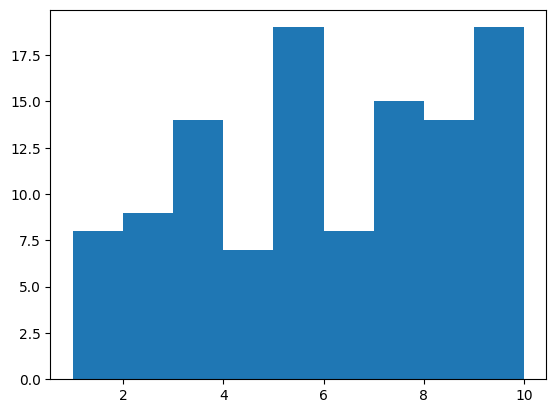

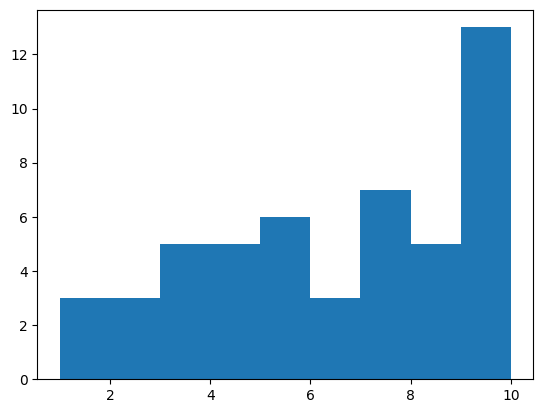

In [47]:
# This first histogram shows the distribution of excited scores
plt.hist(survey['Excited'], bins=np.arange(1, 11))
plt.show()

# This does the same thing, but just for males
plt.hist(survey[survey['Gender']=='Male']['Excited'], bins=np.arange(1, 11))
plt.show()

## Using Value Counts

Suppose we want to know how many people are in each age category. The `value_counts()` method allows use to do this. 

An easy way to use value counts is to put the result into a new dataframe. This allows you to graph the data easily.

Sometimes the counts are not sorted in the way you want, so you need to find a way to sort them.

In [48]:
survey['Gender'].value_counts()

Gender
Female               61
Male                 50
Other                 1
Prefer not to say     1
Name: count, dtype: int64

In [49]:
#  This code puts the Gender value counts into a new dataframe
age_distr = survey['Gender'].value_counts()
age_distr = pd.DataFrame(age_distr)
age_distr.reset_index(inplace=True)
age_distr

,Gender,count
0,Female,61
1,Male,50
2,Other,1
3,Prefer not to say,1


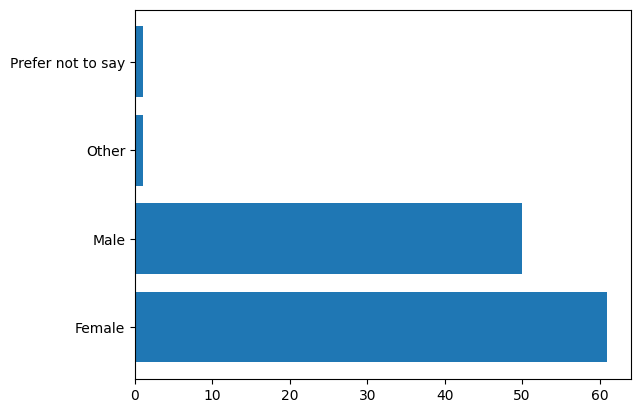

In [50]:
# Now we can create a bar chart
plt.barh(age_distr['Gender'], age_distr['count'])
plt.show()

## Box Plots

We've looked at box plots before. They are a good way to compare numerical data for different groups.

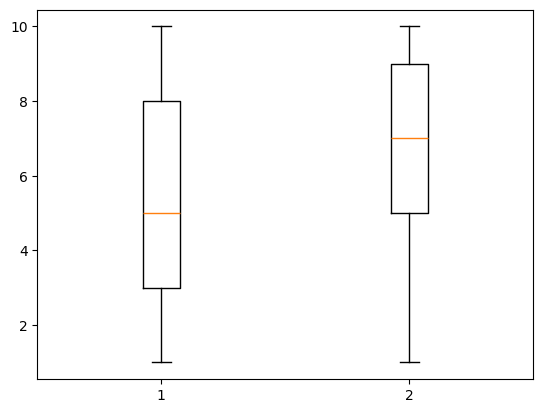

In [54]:
# Use box plots to compare excited versus concerned scores
plt.boxplot([survey['Excited'], survey['Concerned']])
plt.show()